In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from scipy import signal #for the scipy.signal.convolve2d function
from scipy import ndimage #for the scipy.ndimage.maximum_filter

In [10]:
def show_img(img):
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()


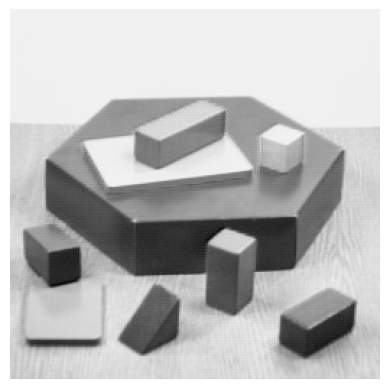

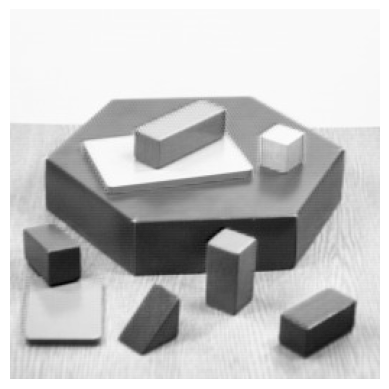

In [12]:
img = cv2.imread('images/blocks.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = gray.astype(float) / 255.0
show_img(img)
show_img(gray)

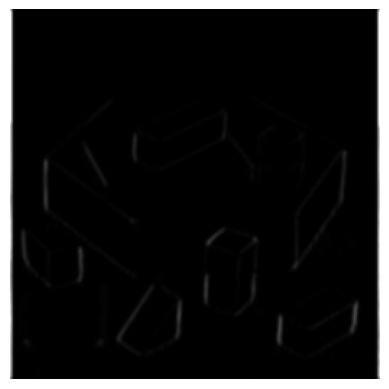

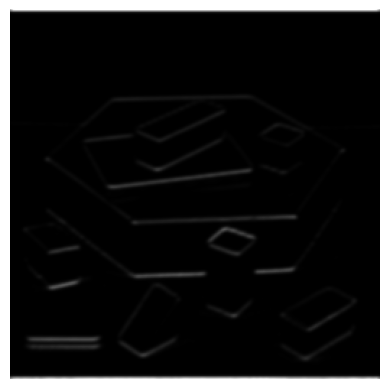

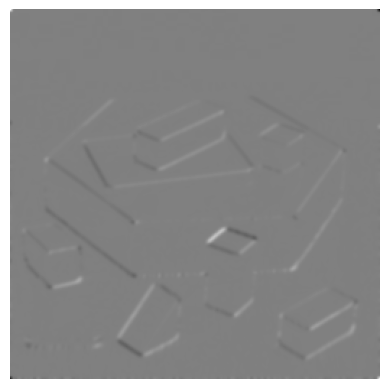

In [4]:
kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
ky = np.array([[-1,-2,-1] ,[0,0,0], [1,2,1]])
dx=signal.convolve2d(gray,kx, "same")
dy=signal.convolve2d(gray,ky, "same")
dx2 = ndimage.gaussian_filter(dx**2, 1.0)
dy2 = ndimage.gaussian_filter(dy**2, 1.0)
dxy = ndimage.gaussian_filter(dx*dy, 1.0)
show_img(dx2)
show_img(dy2)
show_img(dxy)

Min = -4.2165186671129815 Max = 23.851023089758918


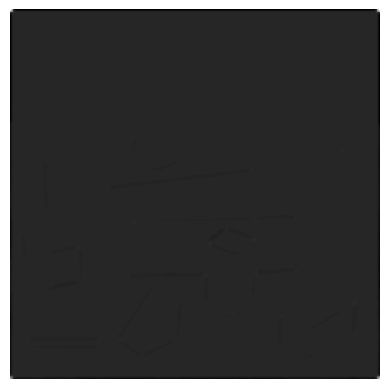

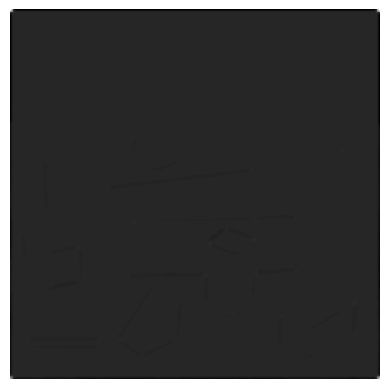

In [14]:
k = 0.05
detA = dx2 * dy2 - dxy ** 2
traceA = dx2 + dy2

C = detA - k * (traceA ** 2)

scaled_C = cv2.normalize(C, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

print(f'Min = {C.min()} Max = {C.max()}')
show_img(C)
show_img(scaled_C)

In [6]:
threshold = 1e-3

Number of corners: 108


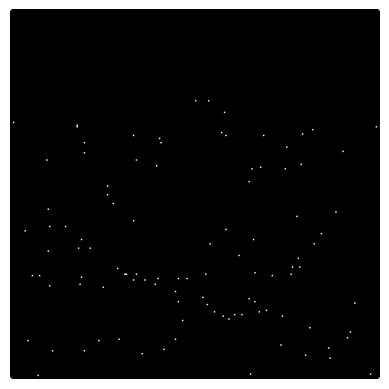

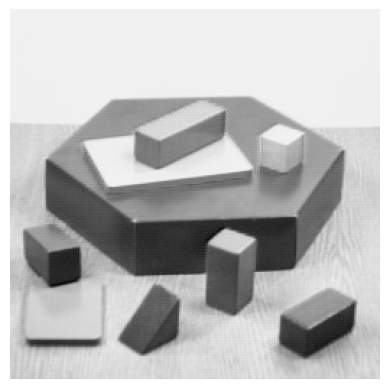

(108, 2)


array([[  0,   0],
       [  0, 255],
       [ 63, 128],
       [ 63, 137],
       [ 71, 148],
       [ 78,   2],
       [ 80,  46],
       [ 81,  46],
       [ 81, 253],
       [ 83, 209],
       [ 85, 146],
       [ 86, 202],
       [ 87,  85],
       [ 87, 149],
       [ 87, 175],
       [ 89, 103],
       [ 92,  51],
       [ 92, 104],
       [ 95, 191],
       [ 98, 230],
       [ 99,  51],
       [104,  25],
       [104,  87],
       [107, 201],
       [108, 101],
       [109, 173],
       [110, 167],
       [110, 190],
       [119, 165],
       [122,  67],
       [128,  67],
       [134,  71],
       [138,  26],
       [140, 225],
       [143, 198],
       [146,  85],
       [150,  27],
       [150,  38],
       [152, 149],
       [153,  10],
       [155, 215],
       [159,  49],
       [159, 168],
       [162, 138],
       [162, 210],
       [165,  47],
       [165,  55],
       [167,  26],
       [170, 158],
       [172, 199],
       [178, 195],
       [178, 200],
       [179,

In [7]:
thresh_mask = C > threshold
C_filtered = ndimage.maximum_filter(C, size=5)
diff_mask = abs(C - C_filtered) < 1e-5
corners = thresh_mask & diff_mask
x,y = np.where(corners)
out = np.stack((x,y), axis=1)
print(f'Number of corners: {np.sum(corners)}')
show_img(corners)
show_img(img)
print(out.shape)
out

In [8]:
patchs = 9
borderreg = patchs//2
borderreg

4